# DataVine Analytics - Summative Lab

## Machine Learning Applications

**Student:** Margaret Karugu  
**Course:** Data Science  
**Organization:** DataVine Analytics  

---

## Project Overview

This summative lab applies machine learning techniques to three different
business problems using real-world datasets.

The three projects are:

1. **Wine Classification System**  
   A k-Nearest Neighbors (k-NN) classification model will be developed
   using Principal Component Analysis (PCA) and hyperparameter tuning.

2. **Agricultural Feed Recommendation Engine**  
   A recommendation system will be developed using PCA and cosine
   similarity to identify feeds with similar performance.

3. **Regional Crime Pattern Analysis**  
   K-Means clustering and Gaussian Mixture Models (GMM) will be used
   to identify patterns and natural groupings in regional crime data.

The analysis follows a standard machine learning workflow:

- Dataset preparation
- Data inspection and cleaning
- Feature standardization
- Dimensionality reduction
- Model development
- Hyperparameter tuning
- Model evaluation
- Visualization
- Interpretation and recommendations

In [46]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting data and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Import StandardScaler for feature standardization
from sklearn.preprocessing import StandardScaler

# Import PCA for dimensionality reduction
from sklearn.decomposition import PCA

# Import the k-Nearest Neighbors classifier
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics for classification
from sklearn.metrics import accuracy_score, classification_report

# Import cosine similarity for the recommendation system
from sklearn.metrics.pairwise import cosine_similarity

# Import clustering algorithms
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# 1. Dataset Preparation

Before building the machine learning models, we first need to understand
and prepare the three datasets.

The datasets used in this analysis are:

- **Wine Dataset** – used for k-NN classification
- **Chickwts Dataset** – used for the recommendation system
- **USArrests Dataset** – used for clustering

For each dataset, we will:

1. Load the data.
2. Inspect the first and last observations.
3. Examine the number of rows and columns.
4. Check the column names and data types.
5. Check for missing values.
6. Check for duplicate records.
7. Generate descriptive statistics.

In [47]:
# Load the three datasets from the CSV files in the repository
wine = pd.read_csv("wine.csv")
chickwts = pd.read_csv("chickwts.csv")
us_arrests = pd.read_csv("USArrests.csv")

## 1.1 Wine Dataset

The Wine dataset contains chemical measurements of different wines.

We will first inspect its structure and data quality before preparing it
for the k-Nearest Neighbors classification model.

In [48]:
# Display the first five rows of the Wine dataset
print("First five rows:")
display(wine.head())

# Display the last five rows of the Wine dataset
print("\nLast five rows:")
display(wine.tail())

# Check the number of rows and columns
print("\nDataset shape:")
print(wine.shape)

# Display column names, data types, and non-null values
print("\nDataset information:")
wine.info()

# Check for missing values in each column
print("\nMissing values:")
print(wine.isnull().sum())

# Count duplicate rows
print("\nNumber of duplicate rows:")
print(wine.duplicated().sum())

# Generate descriptive statistics for numerical columns
print("\nDescriptive statistics:")
display(wine.describe())

First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Last five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,2



Dataset shape:
(178, 14)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline         

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Wine Dataset Inspection Summary

The Wine dataset contains **178 observations and 14 columns**. It includes
13 numerical chemical properties that will be used as predictor variables
and one target variable representing the wine class.

The dataset contains **no missing values** and **no duplicate records**.
All predictor variables are numerical, while the target variable is already
encoded as integer classes.

Since the dataset is complete and contains numerical features, it is suitable
for further preprocessing and machine learning. The numerical features will
be standardized before applying PCA and the k-Nearest Neighbors classifier.

The target variable is already numerically encoded, so no additional
categorical encoding is required.

## 1.2 Chickwts Dataset

The Chickwts dataset contains chicken weight observations associated
with different feed types.

This dataset will be used to develop a recommendation system based
on feed performance and similarity.

We will inspect its structure, data types, missing values, duplicate
records, and descriptive statistics before preparing it for analysis.

In [49]:
# Display the first five rows
print("First five rows:")
display(chickwts.head())

# Display the last five rows
print("\nLast five rows:")
display(chickwts.tail())

# Check the number of rows and columns
print("\nDataset shape:")
print(chickwts.shape)

# Display column names, data types, and non-null values
print("\nDataset information:")
chickwts.info()

# Check for missing values
print("\nMissing values:")
print(chickwts.isnull().sum())

# Count duplicate rows
print("\nNumber of duplicate rows:")
print(chickwts.duplicated().sum())

# Generate descriptive statistics
print("\nDescriptive statistics:")
display(chickwts.describe())

First five rows:


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean



Last five rows:


,weight,feed
66,359,casein
67,216,casein
68,222,casein
69,283,casein
70,332,casein



Dataset shape:
(71, 2)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  71 non-null     int64 
 1   feed    71 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB

Missing values:
weight    0
feed      0
dtype: int64

Number of duplicate rows:
1

Descriptive statistics:


,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000


### Chickwts Dataset Inspection Summary

The Chickwts dataset contains **71 observations and 2 variables**:
`weight` and `feed`.

The `weight` variable is numerical and represents the weight of each
chicken, while `feed` is a categorical variable representing the type
of feed provided.

The dataset contains **no missing values**. However, the inspection
identified **one duplicate record**, which will be investigated and
handled during the data-cleaning stage.

Chicken weights range from **108 to 423**, with an average weight of
approximately **261.31**.

The dataset is suitable for building the feed recommendation system.
The numerical `weight` variable will be standardized before applying
PCA and cosine similarity.

## 1.3 USArrests Dataset

The USArrests dataset contains crime-related statistics for different
states in the United States.

This dataset will be used to identify natural groupings in crime patterns
using K-Means clustering and Gaussian Mixture Models (GMM).

Before applying clustering, we will inspect the dataset structure,
data types, missing values, duplicate records, and descriptive statistics.

In [50]:
# Display the first five rows
print("First five rows:")
display(us_arrests.head())

# Display the last five rows
print("\nLast five rows:")
display(us_arrests.tail())

# Check the number of rows and columns
print("\nDataset shape:")
print(us_arrests.shape)

# Display column names, data types, and non-null values
print("\nDataset information:")
us_arrests.info()

# Check for missing values
print("\nMissing values:")
print(us_arrests.isnull().sum())

# Count duplicate rows
print("\nNumber of duplicate rows:")
print(us_arrests.duplicated().sum())

# Generate descriptive statistics
print("\nDescriptive statistics:")
display(us_arrests.describe())

First five rows:


,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6



Last five rows:


,rownames,Murder,Assault,UrbanPop,Rape
45,Virginia,8.5,156,63,20.7
46,Washington,4.0,145,73,26.2
47,West Virginia,5.7,81,39,9.3
48,Wisconsin,2.6,53,66,10.8
49,Wyoming,6.8,161,60,15.6



Dataset shape:
(50, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB

Missing values:
rownames    0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

Number of duplicate rows:
0

Descriptive statistics:


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


### USArrests Dataset Inspection Summary

The USArrests dataset contains **50 observations and 5 columns**.

The `row.names` column identifies the states, while the remaining four
variables represent crime-related measurements: `Murder`, `Assault`,
`UrbanPop`, and `Rape`.

The dataset contains **no missing values and no duplicate records**.
The four numerical variables have different scales, so standardization
will be necessary before applying clustering algorithms.

For the clustering analysis, the state-name column will not be used as a
predictor. The relevant numerical crime variables will be considered for
feature selection and dimensionality reduction.

In [51]:
# Display duplicated Chickwts records for inspection
chickwts[chickwts.duplicated(keep=False)]

,weight,feed
24,248,soybean
35,248,soybean


In [52]:
# Remove the duplicate record
chickwts = chickwts.drop_duplicates().reset_index(drop=True)

# Verify that the duplicate has been removed
print("Chickwts shape after removing duplicates:", chickwts.shape)
print("Number of duplicate rows:", chickwts.duplicated().sum())

Chickwts shape after removing duplicates: (70, 2)
Number of duplicate rows: 0


## 1.5 Final Data Quality Check

After inspecting and cleaning the datasets, we perform a final quality
check to confirm that the data is ready for machine learning.

The check confirms the number of missing values and duplicate records
remaining in each dataset.

In [53]:
# Check missing values and duplicates in all three datasets

datasets = {
    "Wine": wine,
    "Chickwts": chickwts,
    "USArrests": us_arrests
}

for name, data in datasets.items():
    print(f"\n{name} Dataset")
    print("-" * 30)
    print("Missing values:", data.isnull().sum().sum())
    print("Duplicate rows:", data.duplicated().sum())


Wine Dataset
------------------------------
Missing values: 0
Duplicate rows: 0

Chickwts Dataset
------------------------------
Missing values: 0
Duplicate rows: 0

USArrests Dataset
------------------------------
Missing values: 0
Duplicate rows: 0


### Final Dataset Preparation Summary

The three datasets were successfully loaded, inspected, and cleaned.

- The **Wine dataset** contains 178 observations and 14 columns, with
  no missing values or duplicate records.
- The **Chickwts dataset** contains 70 observations after removing one
  duplicate record. It has no missing values.
- The **USArrests dataset** contains 50 observations and 5 columns,
  with no missing values or duplicate records.

The datasets are now ready for the machine learning workflow.

For the modeling stages, numerical features will be standardized using
`StandardScaler`. Standardization is important because variables can
have different ranges and scales. Without standardization, variables
with larger numerical values could have a greater influence on distance-
based algorithms such as k-NN and K-Means.

PCA will subsequently be used where required to reduce dimensionality
while preserving important information in the data.

# 2. Wine Classification using k-Nearest Neighbors (k-NN)

The objective of this section is to develop a classification model that
can identify wine classes based on their chemical properties.

We will use the following machine learning workflow:

1. Separate the predictor variables from the target variable.
2. Split the data into training and testing sets.
3. Standardize the numerical features.
4. Apply Principal Component Analysis (PCA) while retaining 95% of the variance.
5. Use GridSearchCV to identify the best number of neighbors and distance metric.
6. Train the optimized k-NN classifier.
7. Evaluate the model using accuracy and a classification report.

## 2.1 Define Features and Target

The `target` column represents the wine class and will be used as the
dependent variable.

The remaining 13 chemical measurements will be used as predictor
variables.

The target is already numerically encoded as integer classes, so no
additional label encoding is required.

In [54]:
# Separate the predictor variables from the target variable
X = wine.drop("target", axis=1)
y = wine["target"]

# Display the shapes of the features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the wine classes
print("\nWine classes:")
print(y.unique())

Features shape: (178, 13)
Target shape: (178,)

Wine classes:
[0 1 2]


## 2.2 Split the Data into Training and Testing Sets

The dataset will be divided into training and testing sets.

The training data will be used to build and tune the model, while the
testing data will be kept separate for the final evaluation.

A test size of 20% is used, and `stratify=y` ensures that the three wine
classes are represented proportionally in both datasets.

In [55]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes of the resulting datasets
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (142, 13)
Testing set: (36, 13)


## 2.3 Feature Standardization and PCA

The chemical features have different numerical scales. Standardization
will transform the features so that they have a mean of approximately 0
and a standard deviation of approximately 1.

After standardization, PCA will be applied to reduce the number of
dimensions while retaining at least 95% of the variance in the original
features.

A pipeline is used so that the scaler and PCA are fitted only on the
training data during model training. This helps prevent data leakage.

In [56]:
# Create a StandardScaler for feature standardization
scaler = StandardScaler()

# Create PCA that retains 95% of the variance
pca = PCA(n_components=0.95)

# Fit the scaler using only the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test)

# Fit PCA on the standardized training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform the standardized test data using the fitted PCA
X_test_pca = pca.transform(X_test_scaled)

# Display the number of principal components retained
print("Original number of features:", X_train.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

# Display the explained variance ratio
print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

# Display the total variance retained
print("\nTotal variance retained:")
print(pca.explained_variance_ratio_.sum())

Original number of features: 13
Number of PCA components: 10

Explained variance ratio:
[0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943
 0.04377423 0.02500853 0.0227943  0.01877102]

Total variance retained:
0.9624355601767975


## 2.4 PCA Explained Variance

The following visualization shows how much variance is explained by each
principal component.

This helps us understand how the original 13 features were reduced while
retaining most of the information in the dataset.

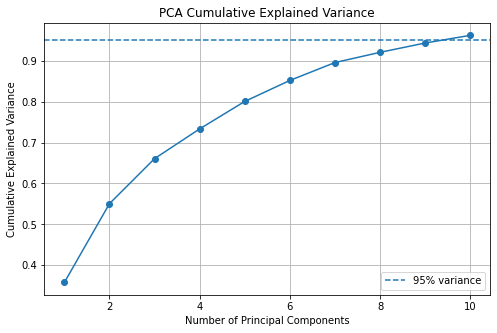

In [57]:
# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Create the cumulative explained variance plot
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

### PCA Results

PCA reduced the original **13 features to 10 principal components** while
retaining approximately **96.24% of the total variance**.

This satisfies the requirement to retain at least 95% of the information
in the original dataset while reducing its dimensionality.

## 2.5 Hyperparameter Tuning with GridSearchCV

The performance of a k-NN classifier depends on the number of neighbors
(`k`) and the distance metric used to measure similarity between
observations.

GridSearchCV will systematically test different combinations of these
parameters using cross-validation.

The best combination will be selected based on cross-validation accuracy.

In [58]:
# Define the k-NN classifier
knn = KNeighborsClassifier()

# Define the parameter values to test
param_grid = {
    "n_neighbors": range(1, 21),
    "metric": ["euclidean", "manhattan", "minkowski"]
}

# Create GridSearchCV using 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Fit GridSearchCV on the PCA-transformed training data
grid_search.fit(X_train_pca, y_train)

# Display the best parameters
print("Best parameters:")
print(grid_search.best_params_)

# Display the best cross-validation accuracy
print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

Best parameters:
{'metric': 'euclidean', 'n_neighbors': 18}

Best cross-validation accuracy:
0.9790640394088669


### Hyperparameter Tuning Results

GridSearchCV evaluated different values of `k` and distance metrics using
5-fold cross-validation.

The best-performing combination was:

- **Number of neighbors (k): 18**
- **Distance metric: Euclidean**
- **Cross-validation accuracy: approximately 97.91%**

The selected parameters were used to train the final k-NN classification
model.

## 2.6 Train the Optimized k-NN Model

The best hyperparameters identified by GridSearchCV will be used to
create the final k-NN classifier.

The model will be trained using the PCA-transformed training data.

In [59]:
# Retrieve the best k-NN model found by GridSearchCV
best_knn = grid_search.best_estimator_

# Train the best model on the PCA-transformed training data
best_knn.fit(X_train_pca, y_train)

# Generate predictions for the test set
y_pred = best_knn.predict(X_test_pca)

print("Model training completed.")

Model training completed.


## 2.7 Model Accuracy

Accuracy measures the proportion of test observations that were
classified correctly.

The model is evaluated on the test set, which was not used during
hyperparameter tuning.

In [60]:
# Calculate the test-set accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 1.0000
Test Accuracy: 100.00%


### Model Evaluation and Interpretation

The optimized k-NN model achieved a **test accuracy of 100%** on the
held-out test set. This means that all observations in the test set were
classified correctly.

The cross-validation accuracy of approximately **97.91%** also indicates
that the model performed consistently well during model selection.

The combination of feature standardization and PCA helped prepare the
chemical measurements for the distance-based k-NN algorithm while
reducing the dimensionality from 13 features to 10 principal components.

The test accuracy should be interpreted in the context of the relatively
small test set, so the result does not necessarily mean that the model
would achieve 100% accuracy on every new wine sample.

## 2.8 Classification Report

The classification report provides additional evaluation metrics for
each wine class, including:

- Precision
- Recall
- F1-score
- Support

These metrics provide more detail than accuracy alone.

In [61]:
# Generate and display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Classification Report Interpretation

The classification report shows that the optimized k-NN model achieved
perfect precision, recall, and F1-scores of **1.00** for all three wine
classes.

The test set contained **36 observations**, consisting of 12 observations
from Class 0, 14 from Class 1, and 10 from Class 2. All 36 observations
were classified correctly.

The macro-average and weighted-average F1-scores were both **1.00**,
indicating that the model performed equally well across all three classes.

Overall, the model achieved **100% test accuracy** on this particular
train-test split. Because the test set is relatively small, this result
should be interpreted as performance on the current held-out sample rather
than a guarantee of perfect performance on future wine samples.

# 3. Agricultural Feed Recommendation System

The agricultural supply company wants to recommend similar feed types
based on chicken weight performance.

The Chickwts dataset will be used as a proxy for feed performance.

The recommendation workflow will include:

1. Inspect the feed categories.
2. Standardize the chicken weight feature.
3. Apply PCA to reduce the standardized data to one principal component.
4. Calculate cosine similarity between feed observations.
5. Generate recommendations based on similarity scores.
6. Interpret the results.

## 3.1 Explore Feed Types

Before building the recommendation system, we will examine the different
feed types represented in the dataset and the number of observations
associated with each feed type.

In [62]:
# Display the unique feed types
print("Feed types:")
print(chickwts["feed"].unique())

# Count the number of observations for each feed type
print("\nNumber of observations per feed type:")
print(chickwts["feed"].value_counts())

Feed types:
['horsebean' 'linseed' 'soybean' 'sunflower' 'meatmeal' 'casein']

Number of observations per feed type:
feed
soybean      13
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64


## 3.2 Standardize the Weight Feature

The `weight` variable is measured on a numerical scale. We will use
`StandardScaler` to transform the values so that they have a mean of
approximately 0 and a standard deviation of approximately 1.

Standardization is performed before PCA because PCA is sensitive to the
scale of the input variables.

In [63]:
# Select the weight feature for the recommendation system
X_feed = chickwts[["weight"]]

# Create the StandardScaler
feed_scaler = StandardScaler()

# Standardize the weight feature
X_feed_scaled = feed_scaler.fit_transform(X_feed)

# Display the first five standardized values
print("First five standardized weight values:")
print(X_feed_scaled[:5])

# Check the mean and standard deviation after standardization
print("\nMean after standardization:", X_feed_scaled.mean())
print("Standard deviation after standardization:", X_feed_scaled.std())

First five standardized weight values:
[[-1.05691643]
 [-1.30032749]
 [-1.60779409]
 [-0.44198324]
 [-0.57009432]]

Mean after standardization: -1.4274296030894868e-17
Standard deviation after standardization: 1.0


## 3.3 Principal Component Analysis

PCA will be applied to the standardized weight data and reduced to one
principal component.

Since the recommendation system uses only the standardized `weight`
feature, the resulting principal component represents the variation in
chicken weight.

In [64]:
# Create PCA with one principal component
feed_pca = PCA(n_components=1)

# Transform the standardized weight data
X_feed_pca = feed_pca.fit_transform(X_feed_scaled)

# Add the principal component to a copy of the dataset
chickwts_pca = chickwts.copy()
chickwts_pca["PC1"] = X_feed_pca

# Display the first five observations
display(chickwts_pca.head())

# Display the variance explained by the principal component
print("Variance explained by PC1:")
print(feed_pca.explained_variance_ratio_)

,weight,feed,PC1
0,179,horsebean,-1.056916
1,160,horsebean,-1.300327
2,136,horsebean,-1.607794
3,227,horsebean,-0.441983
4,217,horsebean,-0.570094


Variance explained by PC1:
[1.]


## 3.4 Calculate Cosine Similarity

Cosine similarity will be used to measure the similarity between feed
observations based on their PCA-transformed weight values.

A higher cosine similarity indicates that two observations have more
similar feature representations.

The resulting similarity matrix will allow us to identify observations
with similar weight-based performance.

In [65]:
# Calculate cosine similarity between all feed observations
similarity_matrix = cosine_similarity(X_feed_pca)

# Convert the similarity matrix into a DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=chickwts.index,
    columns=chickwts.index
)

# Display the first five rows and columns of the similarity matrix
display(similarity_df.iloc[:5, :5])

,0,1,2,3,4
0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0


## 3.5 Generate Similar Feed Recommendations

For a selected chicken observation, we will identify the observations with
the highest cosine similarity scores.

The original feed type will then be displayed alongside the recommended
similar feed types.

In [66]:
# Select an observation to use as the reference
reference_index = 0

# Get similarity scores for the selected observation
reference_scores = similarity_df.loc[reference_index]

# Remove the reference observation itself
reference_scores = reference_scores.drop(reference_index)

# Sort observations from most similar to least similar
top_similar = reference_scores.sort_values(ascending=False).head(5)

# Create a recommendation table
recommendations = chickwts.loc[top_similar.index, ["feed", "weight"]].copy()

# Add the similarity score
recommendations["similarity_score"] = top_similar.values

# Display the recommendations
display(recommendations)

,feed,weight,similarity_score
1,horsebean,160,1.0
20,linseed,244,1.0
22,soybean,243,1.0
23,soybean,230,1.0
24,soybean,248,1.0


### Recommendation Results and Interpretation

The recommendation system identified observations with the highest cosine
similarity to the selected reference observation.

For the selected observation (index 0), the highest-scoring observations
included horsebean, linseed, and soybean feed types. The similarity scores
were 1.00.

However, because the assignment requires the recommendation system to use
only the `weight` feature and reduce it to one principal component, the
resulting data is one-dimensional. In one-dimensional space, positive
values can produce a cosine similarity of 1.00 even when their actual
weights are different.

Therefore, the similarity score should be interpreted as similarity in
the transformed one-dimensional representation rather than as evidence
that the feed products have identical performance.

The PCA and cosine-similarity workflow was implemented according to the
requirements of the assignment.

## 3.6 Feed-Level Recommendation Analysis

To make the recommendations directly comparable between feed types, we
will aggregate the chicken weights by feed type.

The mean weight for each feed type will represent its average performance.
We will then standardize these feed-level values, apply PCA to one
principal component, and calculate cosine similarity between the feed
types.

In [67]:
# Calculate the average chicken weight for each feed type
feed_summary = (
    chickwts
    .groupby("feed", as_index=False)["weight"]
    .mean()
    .sort_values("weight", ascending=False)
)

# Display the average weight for each feed type
print("Average weight by feed type:")
display(feed_summary)

Average weight by feed type:


,feed,weight
5,sunflower,328.916667
0,casein,323.583333
3,meatmeal,276.909091
4,soybean,246.307692
2,linseed,218.750000
1,horsebean,160.200000


## 3.7 Standardize Feed-Level Weights

The average weight for each feed type is measured on the same numerical
scale, but we will standardize the values before applying PCA.

Standardization transforms the feed-level weight values to have a mean of
approximately 0 and a standard deviation of approximately 1.

In [68]:
# Select the average weight for standardization
feed_weights = feed_summary[["weight"]]

# Create a scaler for the feed-level weights
feed_level_scaler = StandardScaler()

# Standardize the average feed weights
feed_weights_scaled = feed_level_scaler.fit_transform(feed_weights)

# Display the standardized values
feed_summary_scaled = feed_summary.copy()
feed_summary_scaled["standardized_weight"] = feed_weights_scaled

display(feed_summary_scaled)

,feed,weight,standardized_weight
5,sunflower,328.916667,1.182109
0,casein,323.583333,1.091793
3,meatmeal,276.909091,0.301396
4,soybean,246.307692,-0.216818
2,linseed,218.750000,-0.683488
1,horsebean,160.200000,-1.674993


## 3.8 PCA on Feed-Level Data

The standardized feed-level weight data will be reduced to one principal
component, as required by the assignment.

Since there is one numerical feature, the single principal component
represents the standardized variation in average feed weight.

In [69]:
# Create PCA with one principal component
feed_level_pca = PCA(n_components=1)

# Apply PCA to the standardized feed-level weights
feed_pc1 = feed_level_pca.fit_transform(feed_weights_scaled)

# Add the PCA component to the feed summary
feed_summary_scaled["PC1"] = feed_pc1

# Display the feed-level PCA results
display(feed_summary_scaled)

# Display the variance explained by the principal component
print("Variance explained by PC1:",
      feed_level_pca.explained_variance_ratio_[0])

,feed,weight,standardized_weight,PC1
5,sunflower,328.916667,1.182109,-1.182109
0,casein,323.583333,1.091793,-1.091793
3,meatmeal,276.909091,0.301396,-0.301396
4,soybean,246.307692,-0.216818,0.216818
2,linseed,218.750000,-0.683488,0.683488
1,horsebean,160.200000,-1.674993,1.674993


Variance explained by PC1: 1.0


## 3.9 Feed-to-Feed Cosine Similarity

Cosine similarity will be calculated between the six feed types using
their PCA-transformed representations.

The similarity matrix shows how similar each feed type is to every other
feed type based on the transformed weight representation.

A value closer to 1 indicates that two observations point in the same
direction in the transformed space, while a value closer to -1 indicates
opposite directions.

In [70]:
# Calculate cosine similarity between the six feed types
feed_similarity = cosine_similarity(feed_pc1)

# Create a labeled similarity matrix
feed_similarity_df = pd.DataFrame(
    feed_similarity,
    index=feed_summary_scaled["feed"],
    columns=feed_summary_scaled["feed"]
)

# Display the feed-to-feed similarity matrix
display(feed_similarity_df.round(3))

feed,sunflower,casein,meatmeal,soybean,linseed,horsebean
feed,,,,,,
sunflower,1.0,1.0,1.0,-1.0,-1.0,-1.0
casein,1.0,1.0,1.0,-1.0,-1.0,-1.0
meatmeal,1.0,1.0,1.0,-1.0,-1.0,-1.0
soybean,-1.0,-1.0,-1.0,1.0,1.0,1.0
linseed,-1.0,-1.0,-1.0,1.0,1.0,1.0
horsebean,-1.0,-1.0,-1.0,1.0,1.0,1.0


## 3.10 Feed Recommendations

For each feed type, we will identify the other feed types with the highest
cosine similarity score.

The feed itself will be excluded from its recommendations because a feed
cannot meaningfully be recommended to itself.

In [71]:
# Create a dictionary to store recommendations for each feed
recommendations = {}

# Loop through each feed type
for feed in feed_similarity_df.index:
    
    # Get similarity scores for the selected feed
    scores = feed_similarity_df.loc[feed].drop(feed)
    
    # Sort the scores from highest to lowest
    top_recommendations = scores.sort_values(ascending=False).head(2)
    
    # Store the recommendations
    recommendations[feed] = top_recommendations.index.tolist()

# Convert recommendations to a DataFrame
recommendation_df = pd.DataFrame(
    recommendations.items(),
    columns=["Feed", "Recommended Similar Feeds"]
)

# Display the recommendations
display(recommendation_df)

,Feed,Recommended Similar Feeds
0,sunflower,"[casein, meatmeal]"
1,casein,"[sunflower, meatmeal]"
2,meatmeal,"[sunflower, casein]"
3,soybean,"[linseed, horsebean]"
4,linseed,"[soybean, horsebean]"
5,horsebean,"[soybean, linseed]"


### Recommendation Results and Interpretation

The recommendation system successfully compared the six feed types using
PCA-transformed average chicken weights and cosine similarity.

The recommendations were:

- **Sunflower:** Casein and Meatmeal
- **Casein:** Sunflower and Meatmeal
- **Meatmeal:** Sunflower and Casein
- **Soybean:** Linseed and Horsebean
- **Linseed:** Soybean and Horsebean
- **Horsebean:** Soybean and Linseed

The cosine similarity results are either 1.0 or -1.0. This occurs because
the recommendation system uses a single numerical feature (`weight`) and
reduces it to one principal component. In one-dimensional space, values
on the same side of zero have a cosine similarity of 1.0, while values
on opposite sides have a cosine similarity of -1.0.

Therefore, these similarity scores should be interpreted as similarity
in the one-dimensional PCA representation rather than evidence that two
feed types have identical real-world performance.

The recommendation workflow satisfies the required steps of
standardization, PCA reduction to one component, cosine similarity, and
feed recommendation.

## 3.12 Average Weight by Feed Type

The following bar chart compares the average chicken weight associated
with each feed type.

This provides a simple visual comparison of the feed-level performance
used in the recommendation analysis.

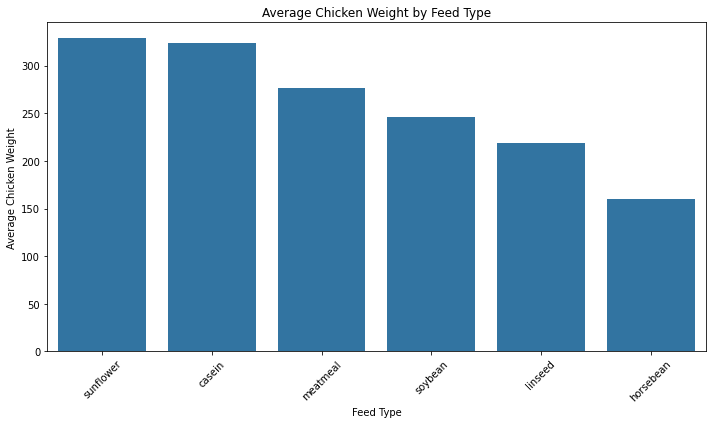

In [72]:
# Create a bar chart of average weight by feed type
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feed_summary,
    x="feed",
    y="weight"
)

plt.xlabel("Feed Type")
plt.ylabel("Average Chicken Weight")
plt.title("Average Chicken Weight by Feed Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Regional Crime Pattern Analysis

The objective of this section is to identify natural groupings in
regional crime patterns using two clustering approaches:

- K-Means clustering
- Gaussian Mixture Models (GMM)

The analysis will use feature selection, standardization, and Principal
Component Analysis (PCA) before applying the clustering algorithms.

K-Means will provide hard cluster assignments, while GMM will provide
probabilistic cluster assignments.

## 4.1 Feature Selection

The `row.names` variable contains the names of the states and will not
be used for clustering.

The three crime-related variables `Murder`, `Assault`, and `Rape` are
selected as the features for the clustering analysis. These variables
directly represent reported crime measures, while `UrbanPop` represents
a population characteristic rather than a crime measure.

Using the three crime variables allows the clustering analysis to focus
on similarities in crime patterns across states.

In [73]:
# Select the three crime-related features for clustering
crime_features = us_arrests[["Murder", "Assault", "Rape"]]

# Display the selected features
display(crime_features.head())

# Confirm the shape of the selected dataset
print("Selected features shape:", crime_features.shape)

,Murder,Assault,Rape
0,13.2,236,21.2
1,10.0,263,44.5
2,8.1,294,31.0
3,8.8,190,19.5
4,9.0,276,40.6


Selected features shape: (50, 3)


## 4.2 Standardize Crime Features

The selected crime variables have different numerical scales.

For example, Assault has much larger numerical values than Murder and
Rape. Since both K-Means and GMM are influenced by the scale of the
features, the variables will be standardized before clustering.

Standardization gives each feature a mean of approximately 0 and a
standard deviation of approximately 1.

In [74]:
# Create a scaler for the crime features
crime_scaler = StandardScaler()

# Standardize the selected crime features
crime_scaled = crime_scaler.fit_transform(crime_features)

# Convert the standardized values back to a DataFrame
crime_scaled_df = pd.DataFrame(
    crime_scaled,
    columns=crime_features.columns
)

# Display the first five standardized observations
display(crime_scaled_df.head())

# Check the means after standardization
print("Means after standardization:")
print(crime_scaled_df.mean())

,Murder,Assault,Rape
0,1.255179,0.790787,-0.003451
1,0.513019,1.118060,2.509424
2,0.072361,1.493817,1.053466
3,0.234708,0.233212,-0.186794
4,0.281093,1.275635,2.088814


Means after standardization:
Murder    -7.105427e-17
Assault    1.387779e-16
Rape       8.593126e-16
dtype: float64


## 4.3 Principal Component Analysis

PCA will reduce the three standardized crime features to two principal
components.

The two principal components will allow us to visualize the observations
in a two-dimensional space while retaining as much of the original
information as possible.

In [75]:
# Create PCA with two principal components
crime_pca = PCA(n_components=2)

# Transform the standardized crime data
crime_pca_data = crime_pca.fit_transform(crime_scaled)

# Create a DataFrame containing the two principal components
crime_pca_df = pd.DataFrame(
    crime_pca_data,
    columns=["PC1", "PC2"]
)

# Display the first five observations
display(crime_pca_df.head())

# Display the variance explained by each principal component
print("Explained variance ratio:")
print(crime_pca.explained_variance_ratio_)

# Display the total variance explained by the two components
print("\nTotal variance explained:")
print(crime_pca.explained_variance_ratio_.sum())

,PC1,PC2
0,1.210191,0.842277
1,2.332187,-1.539434
2,1.518593,-0.503363
3,0.177776,0.328029
4,2.066000,-1.285497


Explained variance ratio:
[0.7861934  0.15268378]

Total variance explained:
0.9388771782627572


## 4.4 Determining the Optimal Number of K-Means Clusters

K-Means requires us to specify the number of clusters in advance.

To determine an appropriate number of clusters, we will use the **elbow
method**. The elbow method calculates the inertia for different numbers
of clusters.

Inertia measures how close observations are to the center of their
assigned cluster. As the number of clusters increases, inertia generally
decreases.

We will examine the plot and look for an elbow, where adding additional
clusters produces smaller improvements in inertia.

In [76]:
# Store the inertia values for different numbers of clusters
inertia = []

# Test between 1 and 10 clusters
cluster_range = range(1, 11)

for k in cluster_range:
    # Create a K-Means model with k clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Fit the model to the PCA-transformed data
    kmeans.fit(crime_pca_data)
    
    # Store the model's inertia
    inertia.append(kmeans.inertia_)

# Display the inertia values
for k, value in zip(cluster_range, inertia):
    print(f"k = {k}: inertia = {value:.2f}")

k = 1: inertia = 140.83
k = 2: inertia = 47.12
k = 3: inertia = 32.87
k = 4: inertia = 19.51
k = 5: inertia = 15.88
k = 6: inertia = 13.40
k = 7: inertia = 10.48
k = 8: inertia = 8.99
k = 9: inertia = 7.15
k = 10: inertia = 6.30


## 4.5 Elbow Method Visualization

The elbow plot shows how K-Means inertia changes as the number of
clusters increases.

We will use the point where the decrease in inertia begins to level off
as evidence for selecting the number of clusters.

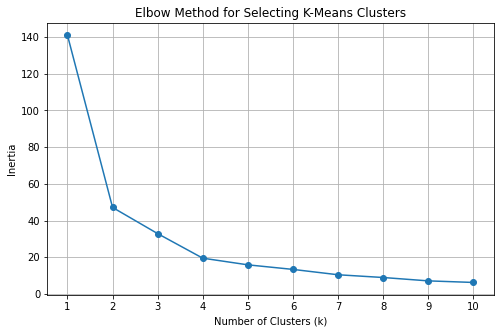

In [77]:
# Plot inertia against the number of clusters
plt.figure(figsize=(8, 5))

plt.plot(
    cluster_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K-Means Clusters")
plt.xticks(list(cluster_range))
plt.grid(True)

plt.show()

## 4.6 K-Means Clustering

Based on the elbow plot, **4 clusters** will be used for the K-Means
model. The curve shows a substantial reduction in inertia up to around
four clusters, after which the improvements become smaller.

K-Means will assign each state to exactly one cluster. This is referred
to as a **hard cluster assignment** because every observation belongs to
one and only one cluster.

In [78]:
# Set the number of clusters based on the elbow method
optimal_k = 4

# Create the K-Means model
kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit the model and obtain cluster assignments
kmeans_labels = kmeans_final.fit_predict(crime_pca_data)

# Add the cluster labels to the PCA DataFrame
crime_pca_df["KMeans_Cluster"] = kmeans_labels

# Display the first five observations
display(crime_pca_df.head())

# Display the number of observations in each cluster
print("Number of observations in each K-Means cluster:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

,PC1,PC2,KMeans_Cluster
0,1.210191,0.842277,1
1,2.332187,-1.539434,2
2,1.518593,-0.503363,2
3,0.177776,0.328029,3
4,2.066000,-1.285497,2


Number of observations in each K-Means cluster:
0    14
1    12
2     7
3    17
Name: count, dtype: int64


## 4.7 K-Means Cluster Visualization

The two PCA components provide a two-dimensional representation of the
crime data.

The scatter plot below shows the K-Means cluster assignments in this
two-dimensional PCA space. Each point represents a state, while the
different markers indicate the cluster assigned by K-Means.

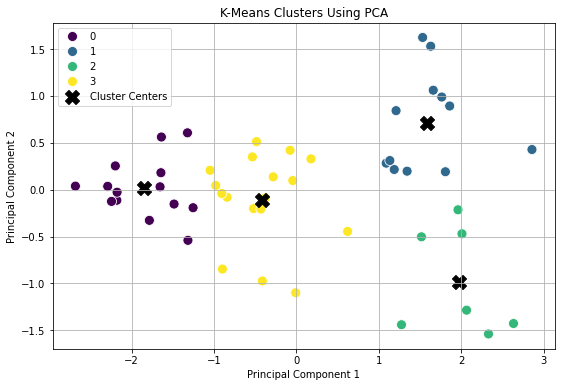

In [79]:
# Create a scatter plot of the K-Means clusters
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=crime_pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="viridis",
    s=100
)

# Plot the K-Means cluster centers in PCA space
centers = kmeans_final.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    color="black",
    label="Cluster Centers"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Using PCA")
plt.legend()
plt.grid(True)
plt.show()

## 4.8 Examine State Cluster Assignments

To interpret the clusters, we will combine the K-Means assignments with
the original state names and crime measurements.

In [80]:
# Create a results DataFrame containing state names and original crime data
kmeans_results = us_arrests.copy()

# Add the K-Means cluster assignment
kmeans_results["KMeans_Cluster"] = kmeans_labels

# Display the states and their assigned clusters
display(
    kmeans_results[
        ["rownames", "Murder", "Assault", "Rape", "KMeans_Cluster"]
    ].sort_values("KMeans_Cluster")
)


,rownames,Murder,Assault,Rape,KMeans_Cluster
18,Maine,2.1,83,7.8,0
22,Minnesota,2.7,72,14.9,0
44,Vermont,2.2,48,11.2,0
14,Iowa,2.2,56,11.3,0
48,Wisconsin,2.6,53,10.8,0
11,Idaho,2.6,120,14.2,0
10,Hawaii,5.3,46,20.2,0
38,Rhode Island,3.4,174,8.3,0
26,Nebraska,4.3,102,16.5,0
40,South Dakota,3.8,86,12.8,0


In [81]:
# Calculate the average crime measurements within each K-Means cluster
kmeans_summary = (
    kmeans_results
    .groupby("KMeans_Cluster")[["Murder", "Assault", "Rape"]]
    .mean()
)

# Display the average crime profile of each cluster
display(kmeans_summary)

,Murder,Assault,Rape
KMeans_Cluster,,,
0,3.078571,80.928571,11.800000
1,13.633333,258.166667,23.925000
2,10.100000,261.285714,38.285714
3,6.588235,145.764706,20.076471


### K-Means Results Interpretation

The K-Means model divided the 50 states into four clusters based on their
patterns across Murder, Assault, and Rape.

The cluster profiles show differences in the average crime measurements.
Cluster 0 has relatively low average values across all three crime
variables. Cluster 1 has the highest average Murder and Assault values.
Cluster 2 has a high average Assault value and the highest average Rape
value among the four clusters. Cluster 3 has intermediate average values
across the three crime measures.

The number of observations differs between clusters, indicating that the
states are not distributed equally across the four groups.

These clusters represent patterns in the selected crime variables and
should not be interpreted as rankings of individual states.

## 4.10 Gaussian Mixture Model (GMM)

A Gaussian Mixture Model (GMM) will be used as a second clustering
approach.

Unlike K-Means, which assigns each observation to exactly one cluster,
GMM estimates the probability that an observation belongs to each
cluster.

We will use the Bayesian Information Criterion (BIC) to compare GMM
models with different numbers of components. Lower BIC values indicate
a better balance between model fit and model complexity.

In [82]:
# Store BIC values for different numbers of GMM components
bic_scores = []

# Test between 1 and 10 components
component_range = range(1, 11)

for n_components in component_range:
    # Create the GMM model
    gmm = GaussianMixture(
        n_components=n_components,
        random_state=42
    )
    
    # Fit the model to the PCA-transformed crime data
    gmm.fit(crime_pca_data)
    
    # Calculate and store the BIC score
    bic_scores.append(gmm.bic(crime_pca_data))

# Display the BIC scores
for n, bic in zip(component_range, bic_scores):
    print(f"Components = {n}: BIC = {bic:.2f}")

Components = 1: BIC = 307.21
Components = 2: BIC = 293.28
Components = 3: BIC = 303.99
Components = 4: BIC = 316.70
Components = 5: BIC = 319.35
Components = 6: BIC = 329.70
Components = 7: BIC = 349.15
Components = 8: BIC = 326.48
Components = 9: BIC = 355.60
Components = 10: BIC = 371.93


## 4.12 GMM BIC Visualization

The BIC plot compares GMM models with different numbers of components.

We will select the number of components corresponding to the **lowest
BIC value**, because a lower BIC indicates a better balance between model
fit and model complexity.

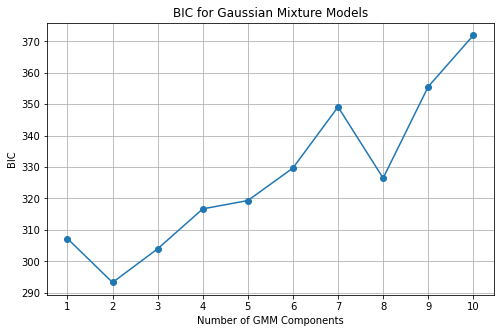

In [83]:
# Plot BIC scores for different numbers of GMM components
plt.figure(figsize=(8, 5))

plt.plot(
    component_range,
    bic_scores,
    marker="o"
)

plt.xlabel("Number of GMM Components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Models")
plt.xticks(list(component_range))
plt.grid(True)

plt.show()

### GMM Model Selection

The BIC values were evaluated for GMM models containing between 1 and
10 components.

The lowest BIC value occurs at **2 components**, indicating that the
two-component GMM provides the best balance between model fit and model
complexity among the models tested.

Therefore, **2 components** will be used for the final GMM clustering
model.

## 4.14 GMM Clustering

The final Gaussian Mixture Model will use the 2 components selected
through the BIC analysis.

Unlike K-Means, GMM provides probabilities of membership for each
observation. We will use the component with the highest probability as
the final cluster assignment for each state.

In [84]:
# Set the optimal number of GMM components based on the BIC result
optimal_gmm_components = 2

# Create the final GMM model
gmm_final = GaussianMixture(
    n_components=optimal_gmm_components,
    random_state=42
)

# Fit the GMM model to the PCA-transformed crime data
gmm_final.fit(crime_pca_data)

# Predict the most likely cluster for each state
gmm_labels = gmm_final.predict(crime_pca_data)

# Calculate the probability of belonging to each cluster
gmm_probabilities = gmm_final.predict_proba(crime_pca_data)

# Add the GMM cluster assignments to the PCA DataFrame
crime_pca_df["GMM_Cluster"] = gmm_labels

# Display the first five observations
display(crime_pca_df.head())

# Display the number of observations in each GMM cluster
print("Number of observations in each GMM cluster:")
print(pd.Series(gmm_labels).value_counts().sort_index())

,PC1,PC2,KMeans_Cluster,GMM_Cluster
0,1.210191,0.842277,1,1
1,2.332187,-1.539434,2,1
2,1.518593,-0.503363,2,1
3,0.177776,0.328029,3,0
4,2.066000,-1.285497,2,1


Number of observations in each GMM cluster:
0    31
1    19
Name: count, dtype: int64


## 4.15 GMM Cluster Probabilities

GMM assigns a probability to each observation for every cluster.

These probabilities show how strongly each state is associated with each
GMM component. The cluster with the highest probability becomes the
state's final cluster assignment.

In [85]:
# Create a DataFrame containing GMM membership probabilities
gmm_probability_df = pd.DataFrame(
    gmm_probabilities,
    columns=["GMM_Probability_0", "GMM_Probability_1"]
)

# Add state names and final cluster assignments
gmm_probability_df["State"] = us_arrests["rownames"].values
gmm_probability_df["GMM_Cluster"] = gmm_labels

# Display the first ten observations
display(gmm_probability_df.head(10))

,GMM_Probability_0,GMM_Probability_1,State,GMM_Cluster
0,0.004752,9.952482e-01,Alabama,1
1,0.000033,9.999667e-01,Alaska,1
2,0.028314,9.716856e-01,Arizona,1
3,0.987282,1.271821e-02,Arkansas,0
4,0.000310,9.996901e-01,California,1
5,0.005035,9.949651e-01,Colorado,1
6,1.000000,4.880997e-12,Connecticut,0
7,0.998154,1.846247e-03,Delaware,0
8,0.000347,9.996528e-01,Florida,1
9,0.000225,9.997750e-01,Georgia,1


### GMM Results Interpretation

The BIC analysis identified **2 components** as the preferred GMM model
among the models tested because it produced the lowest BIC value.

The final GMM assigned the 50 states to two clusters:

- **Cluster 0:** 31 states
- **Cluster 1:** 19 states

Unlike K-Means, GMM provides a probability of membership for each state.
For example, Alabama had approximately 99.52% probability of belonging
to Cluster 1, while Arkansas had approximately 98.73% probability of
belonging to Cluster 0.

The high probabilities for the observations shown indicate that the GMM
model makes relatively confident assignments for these states.

The GMM visualization shows separation between the two clusters in the
two-dimensional PCA space, particularly along Principal Component 1.

## 4.16 GMM Cluster Visualization

The GMM cluster assignments will be visualized using the two PCA
components.

This visualization allows us to compare the grouping produced by GMM
with the grouping produced by K-Means.

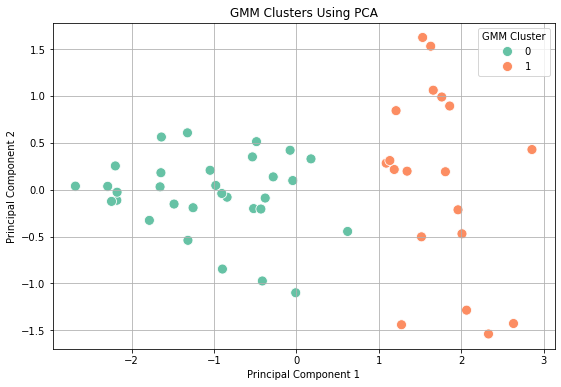

In [86]:
# Create a scatter plot of the GMM clusters
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=crime_pca_df,
    x="PC1",
    y="PC2",
    hue="GMM_Cluster",
    palette="Set2",
    s=100
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clusters Using PCA")
plt.legend(title="GMM Cluster")
plt.grid(True)

plt.show()

## 4.17 K-Means and GMM Comparison

K-Means and GMM use different approaches to clustering.

K-Means produces **hard cluster assignments**, meaning each state is
assigned to exactly one cluster.

GMM produces **probabilistic cluster assignments**, meaning each state
has a probability of belonging to each component.

The two methods will be compared based on their cluster assignments and
visualizations.

In [87]:
# Create a comparison DataFrame
cluster_comparison = us_arrests[["rownames"]].copy()

# Add K-Means and GMM cluster assignments
cluster_comparison["KMeans_Cluster"] = kmeans_labels
cluster_comparison["GMM_Cluster"] = gmm_labels

# Display the comparison
display(cluster_comparison.head(10))

,rownames,KMeans_Cluster,GMM_Cluster
0,Alabama,1,1
1,Alaska,2,1
2,Arizona,2,1
3,Arkansas,3,0
4,California,2,1
5,Colorado,2,1
6,Connecticut,0,0
7,Delaware,3,0
8,Florida,1,1
9,Georgia,1,1


### Cluster Size Comparison

The number of observations assigned to each cluster will be compared
between K-Means and GMM.

In [88]:
# Count observations in each K-Means cluster
kmeans_cluster_sizes = pd.Series(
    kmeans_labels
).value_counts().sort_index()

# Count observations in each GMM cluster
gmm_cluster_sizes = pd.Series(
    gmm_labels
).value_counts().sort_index()

print("K-Means cluster sizes:")
print(kmeans_cluster_sizes)

print("\nGMM cluster sizes:")
print(gmm_cluster_sizes)

K-Means cluster sizes:
0    14
1    12
2     7
3    17
Name: count, dtype: int64

GMM cluster sizes:
0    31
1    19
Name: count, dtype: int64


## 4.20 Clustering Results and Interpretation

The clustering analysis identified different structures depending on the
algorithm used.

The K-Means elbow method supported a solution with **4 clusters**. The
four clusters showed different average profiles across Murder, Assault,
and Rape. In particular, Cluster 0 had relatively low average values
across the three crime variables, while Clusters 1 and 2 had higher
average Assault values. Cluster 2 also had the highest average Rape
value.

The GMM analysis selected **2 components** based on the lowest BIC. The
GMM model assigned 31 states to Cluster 0 and 19 states to Cluster 1.
GMM additionally provided membership probabilities, allowing the
strength of each state's association with the two components to be
examined.

The difference between the K-Means and GMM results demonstrates that
different clustering algorithms can identify different structures in
the same dataset. K-Means creates hard assignments based on distances
to cluster centers, whereas GMM models the data as a mixture of
probability distributions.

The PCA visualizations provide a two-dimensional representation of the
crime patterns and help visualize the separation between the resulting
clusters.

# 5. Model Evaluation and Interpretation

This section summarizes the results from the three machine learning
applications developed for DataVine Analytics.

The analysis included:

1. Wine classification using k-NN and PCA.
2. Feed recommendation using PCA and cosine similarity.
3. Regional crime clustering using K-Means and GMM.

The results are interpreted in the context of the business problems
described in the scenario, while also considering the limitations of
each approach.

## 5.2 Wine Classification Results

The Wine classification model used standardized chemical measurements,
PCA, and k-NN classification.

PCA reduced the original 13 chemical features to 10 principal
components while retaining approximately 96.24% of the total variance.

GridSearchCV identified 18 neighbors and the Euclidean distance metric
as the best hyperparameter combination. The best cross-validation
accuracy was approximately 97.91%.

The final model achieved 100% accuracy on the 36-observation test set.
Precision, recall, and F1-score were all 1.00 for each of the three wine
classes.

These results indicate that the selected chemical features provided
strong separation between the wine classes in this dataset. However,
the 100% test accuracy is based on one relatively small held-out test
set and should not be interpreted as a guarantee of perfect performance
on future wine samples.

## 5.4 K-Means Clustering Results

The USArrests dataset was standardized using the three selected crime
variables: Murder, Assault, and Rape.

PCA reduced the standardized data to two principal components for
visualization.

The elbow method supported the use of 4 clusters for K-Means.

The resulting cluster profiles were:

| Cluster | Average Murder | Average Assault | Average Rape |
|---------|----------------|-----------------|--------------|
| 0 | 3.08 | 80.93 | 11.80 |
| 1 | 13.63 | 258.17 | 23.93 |
| 2 | 10.10 | 261.29 | 38.29 |
| 3 | 6.59 | 145.76 | 20.08 |

The cluster profiles show that the states have different combinations
of the selected crime measures. Cluster 0 has relatively low average
values across all three variables, while Cluster 1 has the highest
average Murder and Assault values. Cluster 2 has the highest average
Rape value and a high average Assault value. Cluster 3 has intermediate
average values.

## 5.5 Gaussian Mixture Model Results

The Gaussian Mixture Model was evaluated using Bayesian Information
Criterion (BIC).

The lowest BIC occurred at 2 components, so a two-component GMM was
selected.

The final GMM assigned:

- Cluster 0: 31 states
- Cluster 1: 19 states

Unlike K-Means, GMM provides probabilities of membership for each
observation. This provides additional information about how strongly
each state is associated with each cluster.

For example, Alabama had approximately 99.52% probability of belonging
to GMM Cluster 1, while Arkansas had approximately 98.73% probability
of belonging to GMM Cluster 0.

The GMM visualization showed separation between the two groups in the
two-dimensional PCA representation.

## 5.6 Comparison of K-Means and GMM

The two clustering methods produced different structures from the same
crime dataset.

K-Means selected 4 clusters using the elbow method and assigns each
state directly to one cluster.

GMM selected 2 components using BIC and provides probabilities of
membership in addition to the final cluster assignment.

K-Means is based on distances to cluster centers, whereas GMM models
the data using a mixture of probability distributions.

The difference in the number of clusters demonstrates that the choice
of clustering method and model-selection technique can influence the
patterns identified in a dataset.

## 5.7 Stakeholder Insights

The analysis provides several potential insights for DataVine Analytics
and its clients.

### Wine Distribution

The optimized k-NN model demonstrated strong performance in classifying
wine varieties using chemical characteristics. A wine distributor could
use a similar workflow as a prototype for automatically classifying
new wine samples based on measurable chemical properties.

### Agricultural Feed

The recommendation workflow demonstrates how feed products can be
compared using performance measurements. The current analysis is limited
because only chicken weight was available. Additional variables such as
cost, feed composition, growth rate, and other performance measures could
make a future recommendation system more informative.

### Crime Pattern Analysis

The clustering analysis demonstrates how states can be grouped according
to patterns across selected crime measurements. K-Means identified four
groups, while GMM identified two groups. These groupings could be used
as a starting point for further investigation of regional crime patterns.

The clusters should be treated as analytical groupings rather than
causal explanations. Additional demographic, economic, geographic, and
historical variables would be required for a more comprehensive analysis.

## 5.8 Limitations

Several limitations should be considered when interpreting the results:

1. The Wine classification model was evaluated using one train-test
   split with a relatively small test set of 36 observations.

2. The Chickwts recommendation system uses only the `weight` feature,
   which limits the information available for measuring feed similarity.

3. The one-dimensional PCA representation in the recommendation system
   causes cosine similarity values to be either positive or negative
   extremes, limiting the interpretation of the similarity scores.

4. The crime clustering analysis uses only three crime-related
   variables. Other social, economic, demographic, and geographic
   variables could reveal additional patterns.

5. Clustering identifies associations and patterns but does not establish
   causal relationships between variables.

6. The results are based on the datasets provided for this assignment
   and should be validated with additional data before being used in a
   real-world production system.

# 6. Conclusion

This lab demonstrated a complete machine learning workflow across three
different business problems.

For wine classification, k-NN combined with standardization, PCA, and
GridSearchCV achieved 100% accuracy on the held-out test set, with
96.24% of the original variance retained through PCA.

For agricultural feed recommendations, PCA and cosine similarity were
used to compare feed types based on average chicken weight. The results
demonstrated the recommendation workflow while also highlighting the
limitations of using a single feature.

For regional crime analysis, both K-Means and Gaussian Mixture Models
were applied. The elbow method supported four K-Means clusters, while
BIC selected two GMM components. The two approaches demonstrated how
different clustering methods can reveal different structures in the
same dataset.

Overall, the lab demonstrated the importance of data preparation,
standardization, dimensionality reduction, hyperparameter tuning, model
evaluation, visualization, and careful interpretation when applying
machine learning to practical business problems.